In [27]:
import illustris_python as il
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib as mpl
import h5py   

In [2]:
ptNumGas = il.snapshot.partTypeNum('gas')

In [2]:
basePath = "/cosma7/data/dp004/dc-zhan5/TNG300-3/ics"

In [96]:
basePath = "/cosma7/data/dp004/dc-zhan5/TNG300-3-Dark/snapshot"

In [ ]:
il.loadSnap

In [100]:
fields = ['Coordinates']
dm_coords = il.snapshot.loadSubset(basePath,40,'dm',fields=fields)

In [101]:
dm_coords

array([[ 58482.74596953,   9336.33229119,  99353.02546429],
       [ 58505.75311991,   9353.93067196,  99365.30421788],
       [ 58481.41990809,   9357.87682214,  99355.74244074],
       ...,
       [166097.21560115, 164032.61146119, 123755.23385013],
       [164160.97075232, 164118.40772639, 165457.90370614],
       [164655.06112705, 160706.69150655,    182.24003285]])

In [102]:
type(dm_coords)

numpy.ndarray

In [5]:
fname = f"{basePath}/snap_ics.hdf5"

In [1]:
from nbodykit.source.catalog import HDFCatalog

In [6]:
arraycat = HDFCatalog(fname)

In [22]:
arraycat


HDFCatalog(size=244140625, FileStack(HDFFile(path=/cosma7/data/dp004/dc-zhan5/TNG300-3/ics/snap_ics.hdf5, dataset=/, ncolumns=3, shape=(244140625,)>, ... 1 files))

In [23]:
arraycat.columns

['PartType1/Coordinates',
 'PartType1/ParticleIDs',
 'PartType1/Velocities',
 'Selection',
 'Value',
 'Weight']

In [24]:
arraycat["PartType1/Coordinates"]

dask.array<truediv, shape=(244140625, 3), dtype=float32, chunksize=(100000, 3)>

In [7]:
len(arraycat)

244140625

In [12]:
arraycat["PartType1/Coordinates"] /=1e3

In [13]:
len(arraycat["PartType1/Coordinates"])

244140625

In [21]:
print(arraycat["PartType1/Coordinates"][:,0][-10:])

dask.array<getitem, shape=(10,), dtype=float32, chunksize=(10,)> first: 204.99095 last: 204.99892


In [28]:
f1 = h5py.File(fname,'r')

In [16]:
f1.keys()

<KeysViewHDF5 ['Header', 'PartType1']>

In [46]:
f1["Header"]

<HDF5 group "/Header" (0 members)>

In [29]:
f1["PartType1"]["Coordinates"]

<HDF5 dataset "Coordinates": shape (244140625, 3), type "<f4">

In [25]:
len(f1["PartType1"]["Coordinates"][:,0])

244140625

In [22]:
f1["PartType1"].keys()

<KeysViewHDF5 ['Coordinates', 'ParticleIDs', 'Velocities']>

In [32]:
sfr1 = np.ones_like(f1["PartType1"]["Coordinates"][:,0])

In [28]:
sfr1.shape[0]

244140625

In [30]:
mask = sfr1 > 0

In [29]:
len(f1["PartType1"]["Coordinates"])

244140625

In [36]:
f1["PartType1"]["Coordinates"]

<HDF5 dataset "Coordinates": shape (244140625, 3), type "<f4">

In [35]:
f1["PartType1"]["Coordinates"][mask]

TypeError: Boolean indexing array has incompatible shape

In [31]:
f1["PartType1"]["Coordinates"][:10]/1e3

array([[2.68441796e-01, 1.57909676e-01, 1.54816151e-01],
       [3.36656451e-01, 2.04429850e-01, 4.12144775e+01],
       [2.91176915e-01, 1.36107072e-01, 8.22156525e+01],
       [3.39211881e-01, 1.96761250e-01, 1.23213196e+02],
       [3.21379811e-01, 1.79491222e-01, 1.64131943e+02],
       [2.94834465e-01, 4.11941948e+01, 1.14289828e-01],
       [2.17636228e-01, 4.11655769e+01, 4.12450943e+01],
       [2.79802561e-01, 4.11794662e+01, 8.22379227e+01],
       [3.31832349e-01, 4.11953545e+01, 1.23190056e+02],
       [2.44200915e-01, 4.11926651e+01, 1.64221100e+02]], dtype=float32)

In [53]:
len(f1["PartType1"]["Coordinates"])

244140625

In [47]:
x = f1["PartType1"]["Coordinates"][:,0]/1e3
y = f1["PartType1"]["Coordinates"][:,1]/1e3

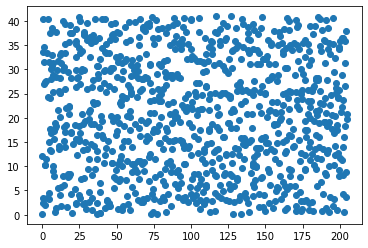

In [60]:
iend = 244140625
step = 250000
plt.scatter(x[:iend:step], y[:iend:step])

In [64]:
from nbodykit.source.catalog import HDFCatalog
f = HDFCatalog(fname)

In [67]:
f.columns

['PartType1/Coordinates',
 'PartType1/ParticleIDs',
 'PartType1/Velocities',
 'Selection',
 'Value',
 'Weight']

In [70]:
f['PartType1/Coordinates']

dask.array<array, shape=(244140625, 3), dtype=float32, chunksize=(100000, 3)>

In [71]:
print(f['PartType1/Coordinates'])

dask.array<array, shape=(244140625, 3), dtype=float32, chunksize=(100000, 3)> first: [268.4418  157.90968 154.81615] last: [204998.92 195473.84 199965.72]


In [73]:
print((f['PartType1/Coordinates']/1e3)[:10])

dask.array<getitem, shape=(10, 3), dtype=float32, chunksize=(10, 3)>


In [74]:
f['PartType1/Coordinates'] = f['PartType1/Coordinates']/1e3

In [75]:
print(f['PartType1/Coordinates'])

dask.array<truediv, shape=(244140625, 3), dtype=float32, chunksize=(100000, 3)> first: [0.2684418  0.15790968 0.15481615] last: [204.99892 195.47385 199.96571]


In [76]:
print(f)

HDFCatalog(size=244140625, FileStack(HDFFile(path=/cosma7/data/dp004/dc-zhan5/TNG300-3/ics/snap_ics.hdf5, dataset=/, ncolumns=3, shape=(244140625,)>, ... 1 files))


In [79]:
Nmesh = 100

In [82]:
mesh = f.to_mesh(BoxSize=205, Nmesh=Nmesh, compensated=True, interlaced=True, position = 'PartType1/Coordinates')

In [89]:
density = mesh.preview(Nmesh=16, axes=(1,2))

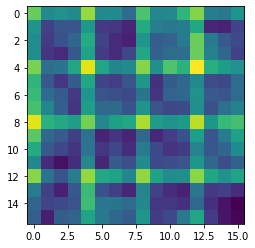

In [90]:
plt.imshow(density)

In [88]:
print(f['PartType1/Coordinates'])

dask.array<truediv, shape=(244140625, 3), dtype=float32, chunksize=(100000, 3)> first: [0.2684418  0.15790968 0.15481615] last: [204.99892 195.47385 199.96571]
